# Credit Risk PD Modeling: Survival Analysis vs Logistic Regression
 
This project models **time-to-default** (not just whether a loan defaults) on ~2 million
Lending Club loans using survival analysis, benchmarks it against a standard logistic
regression approach, and connects the results to IFRS 9 expected credit loss (ECL)
provisioning.
 

## 1. Data Loading & Initial Exploration
 
Loading the Lending Club dataset and checking its shape, columns, and the distribution of
`loan_status` to understand what we're working with before any cleaning.
 

In [2]:
import pandas as pd 
import numpy as np 

In [4]:
loan= pd.read_csv("loan.csv.zip")
loan.head()

C:\Users\MM COMPUTERS\AppData\Local\Temp\ipykernel_15152\967628716.py:1: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  loan= pd.read_csv("loan.csv.zip")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
loan.shape

(2260668, 145)

In [9]:
loan.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [10]:
loan['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

## 2. Data Cleaning & Feature Selection
 
Dropping irrelevant columns (IDs, URLs, free-text fields), filtering to the loan statuses
relevant for this analysis (Fully Paid, Current, Charged Off, Default), and narrowing down
to the ~21 columns that will be used going forward.

In [11]:
# Step 1: Drop unnecessary columns first (this alone will help a lot — many columns are useless for your project)
loan = loan.drop(columns=['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code'])

# Step 2: Keep only the loan_status categories we care about
keep_statuses = ['Fully Paid', 'Charged Off', 'Current', 'Default']
loan = loan[loan['loan_status'].isin(keep_statuses)]

# Step 3: Check size now
print(loan.shape)
print(loan['loan_status'].value_counts())

(2223333, 138)
loan_status
Fully Paid     1041952
Current         919695
Charged Off     261655
Default             31
Name: count, dtype: int64


In [13]:
columns_needed = [
    'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'loan_status', 'purpose', 'dti', 'delinq_2yrs',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'last_pymnt_d', 'addr_state'
]

loan = loan[columns_needed]

print(loan.shape)
loan.info()

(2223333, 21)
<class 'pandas.DataFrame'>
Index: 2223333 entries, 0 to 2260667
Data columns (total 21 columns):
 #   Column               Dtype  
---  ------               -----  
 0   loan_amnt            int64  
 1   term                 str    
 2   int_rate             float64
 3   grade                str    
 4   sub_grade            str    
 5   emp_length           str    
 6   home_ownership       str    
 7   annual_inc           float64
 8   verification_status  str    
 9   issue_d              str    
 10  loan_status          str    
 11  purpose              str    
 12  dti                  float64
 13  delinq_2yrs          float64
 14  open_acc             float64
 15  pub_rec              float64
 16  revol_bal            int64  
 17  revol_util           float64
 18  total_acc            float64
 19  last_pymnt_d         str    
 20  addr_state           str    
dtypes: float64(8), int64(2), str(11)
memory usage: 373.2 MB


In [14]:
loan.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,...,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_d,addr_state
0,2500,36 months,13.56,C,C1,10+ years,RENT,55000.0,Not Verified,Dec-2018,...,debt_consolidation,18.24,0.0,9.0,1.0,4341,10.3,34.0,Feb-2019,NY
1,30000,60 months,18.94,D,D2,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,...,debt_consolidation,26.52,0.0,13.0,1.0,12315,24.2,44.0,Feb-2019,LA
2,5000,36 months,17.97,D,D1,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,...,debt_consolidation,10.51,0.0,8.0,0.0,4599,19.1,13.0,Feb-2019,MI
3,4000,36 months,18.94,D,D2,10+ years,MORTGAGE,92000.0,Source Verified,Dec-2018,...,debt_consolidation,16.74,0.0,10.0,0.0,5468,78.1,13.0,Feb-2019,WA
4,30000,60 months,16.14,C,C4,10+ years,MORTGAGE,57250.0,Not Verified,Dec-2018,...,debt_consolidation,26.35,0.0,12.0,0.0,829,3.6,26.0,Feb-2019,MD


## 3. Constructing Duration and Event Variables
 
Converting `issue_d` and `last_pymnt_d` to proper dates, then computing `duration` (months
between loan issuance and the last observed payment) and `event` (1 = defaulted via Charged
Off/Default, 0 = censored — either Fully Paid or still Current). Both "Fully Paid" and
"Current" are treated as censored: Fully Paid means we know the loan completed without
default, while Current means the loan is still ongoing and hasn't defaulted yet.

In [28]:
loan['issue_d']=pd.to_datetime(loan['issue_d'], format='mixed')
loan['last_pymnt_d']=pd.to_datetime(loan['last_pymnt_d'], format='mixed')


In [24]:
loan.dropna(inplace = True)

In [29]:
loan.info()

<class 'pandas.DataFrame'>
Index: 2075694 entries, 0 to 2260667
Data columns (total 22 columns):
 #   Column               Dtype         
---  ------               -----         
 0   loan_amnt            int64         
 1   term                 str           
 2   int_rate             float64       
 3   grade                str           
 4   sub_grade            str           
 5   emp_length           str           
 6   home_ownership       str           
 7   annual_inc           float64       
 8   verification_status  str           
 9   issue_d              datetime64[us]
 10  loan_status          str           
 11  purpose              str           
 12  dti                  float64       
 13  delinq_2yrs          float64       
 14  open_acc             float64       
 15  pub_rec              float64       
 16  revol_bal            int64         
 17  revol_util           float64       
 18  total_acc            float64       
 19  last_pymnt_d         datetime64[us]
 

In [31]:
year_start = loan['issue_d'].dt.year
month_start = loan['issue_d'].dt.month

year_end = loan['last_pymnt_d'].dt.year
month_end = loan['last_pymnt_d'].dt.month

loan['duration'] = (year_end - year_start) * 12 + (month_end - month_start)

In [32]:
loan['duration'].describe()

count    2.075694e+06
mean     1.926575e+01
std      1.247990e+01
min      0.000000e+00
25%      9.000000e+00
50%      1.700000e+01
75%      2.900000e+01
max      7.000000e+01
Name: duration, dtype: float64

In [34]:
loan['duration'].isna().sum()

np.int64(0)

In [35]:
loan.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,...,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_d,addr_state,last_pymnt_d,duration
0,2500,36 months,13.56,C,C1,10+ years,RENT,55000.0,Not Verified,2018-12-01,...,0.0,9.0,1.0,4341,10.3,34.0,2019-02-01,NY,2019-02-01,2
1,30000,60 months,18.94,D,D2,10+ years,MORTGAGE,90000.0,Source Verified,2018-12-01,...,0.0,13.0,1.0,12315,24.2,44.0,2019-02-01,LA,2019-02-01,2
2,5000,36 months,17.97,D,D1,6 years,MORTGAGE,59280.0,Source Verified,2018-12-01,...,0.0,8.0,0.0,4599,19.1,13.0,2019-02-01,MI,2019-02-01,2
3,4000,36 months,18.94,D,D2,10+ years,MORTGAGE,92000.0,Source Verified,2018-12-01,...,0.0,10.0,0.0,5468,78.1,13.0,2019-02-01,WA,2019-02-01,2
4,30000,60 months,16.14,C,C4,10+ years,MORTGAGE,57250.0,Not Verified,2018-12-01,...,0.0,12.0,0.0,829,3.6,26.0,2019-02-01,MD,2019-02-01,2


### Sanity Check: Duration Exceeding Loan Term

Checking for loans where duration exceeds the maximum possible loan term (60 months) — these would indicate either a data issue or a real-world delay between a loan's official maturity and its final recorded payment. Found ~3,014 rows (0.14% of the dataset) with duration up to 70 months, mostly 60-month loans with a final "Fully Paid" payment posted 1-10 months after the official maturity date — a realistic processing delay, not a data error. Given the negligible share of the dataset affected, these rows were retained as-is.

In [37]:
loan['duration'].isna().sum()

np.int64(0)

In [36]:
loan.shape

(2075694, 23)

In [38]:
loan[loan['duration'] > 60][['term', 'issue_d', 'last_pymnt_d', 'duration', 'loan_status']].head(10)

,term,issue_d,last_pymnt_d,duration,loan_status
1675707,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675722,60 months,2013-12-01,2019-02-01,62,Fully Paid
1675811,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675833,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675862,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675868,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675932,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675961,60 months,2013-12-01,2019-01-01,61,Fully Paid
1675993,60 months,2013-12-01,2019-01-01,61,Fully Paid
1676019,60 months,2013-12-01,2019-01-01,61,Fully Paid


In [39]:
(loan['duration'] > 60).sum()

np.int64(3014)

In [40]:
loan.columns.tolist()

['loan_amnt',
 'term',
 'int_rate',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'dti',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'last_pymnt_d',
 'addr_state',
 'last_pymnt_d  ',
 'duration']

In [41]:
loan[['last_pymnt_d', 'last_pymnt_d  ']].dtypes

last_pymnt_d      datetime64[us]
last_pymnt_d      datetime64[us]
dtype: object

In [42]:
loan[['last_pymnt_d', 'last_pymnt_d  ']].head()

,last_pymnt_d,last_pymnt_d
0,2019-02-01,2019-02-01
1,2019-02-01,2019-02-01
2,2019-02-01,2019-02-01
3,2019-02-01,2019-02-01
4,2019-02-01,2019-02-01


In [43]:
loan = loan.drop(columns=['last_pymnt_d  '])  # or whichever one is the leftover

In [44]:
loan.columns.tolist()

['loan_amnt',
 'term',
 'int_rate',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'dti',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'last_pymnt_d',
 'addr_state',
 'duration']

In [47]:
loan['loan_status']

0             Current
1             Current
2             Current
3             Current
4             Current
              ...    
2260662       Current
2260663       Current
2260664    Fully Paid
2260665       Current
2260667       Current
Name: loan_status, Length: 2075694, dtype: str

In [48]:
loan['loan_status'].value_counts()

loan_status
Fully Paid     986272
Current        850313
Charged Off    239081
Default            28
Name: count, dtype: int64

In [49]:
loan['event'] = loan['loan_status'].isin(['Charged Off', 'Default']).astype(int)

In [50]:
loan['event'].value_counts()

event
0    1836585
1     239109
Name: count, dtype: int64

In [51]:
loan.groupby('event')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
0,1836585.0,19.682158,12.726765,0.0,9.0,18.0,30.0,70.0
1,239109.0,16.067346,9.817892,0.0,8.0,14.0,22.0,66.0


## 4. Kaplan-Meier Survival Analysis


In [55]:
pip install lifelines 

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.1 MB 7.0 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/11.1 MB 7.7 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.1 MB 7.7 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.1 MB 7.5 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.1 MB 7.7 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.1 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 8.0 MB/s  0:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.

  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\MM COMPUTERS\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


### 4.1 Overall Survival Curve
 
The overall Kaplan-Meier curve shows the probability of a loan not having defaulted at each
point in its life. It declines steadily from 1.0 to roughly 0.69 by month 60, meaning
about 31% of loans default by the end of a typical loan term. Estimates beyond month 60
are unreliable due to the small number of loans remaining in the risk set at that point.

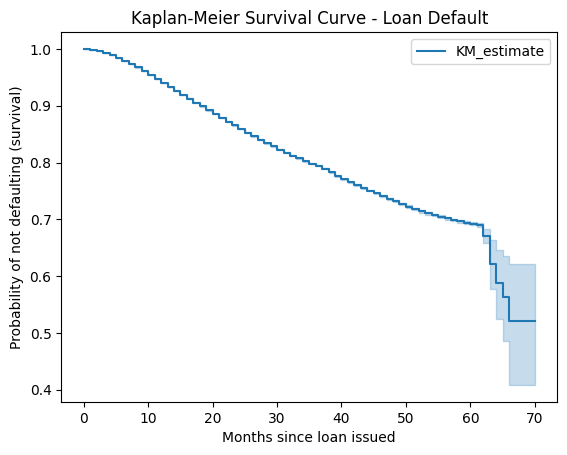

In [56]:
import lifelines 
from lifelines import KaplanMeierFitter , CoxPHFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

kmf.fit(durations=loan['duration'], event_observed=loan['event'])

kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve - Loan Default")
plt.xlabel("Months since loan issued")
plt.ylabel("Probability of not defaulting (survival)")
plt.show()

In [57]:
kmf.survival_function_.tail()

,KM_estimate
timeline,
65.0,0.563496
66.0,0.520150
67.0,0.520150
69.0,0.520150
70.0,0.520150


### 4.2 Survival Curves Stratified by Grade
 
Splitting the Kaplan-Meier curve by loan grade (A-G) shows a clear, monotonic separation:
grade A loans survive far longer without defaulting than grade G loans. By month 60, grade
A sits around 0.89 (11% defaulted) while grade G sits around 0.37-0.40 (over 60%
defaulted) — strong visual evidence that Lending Club's grading system reflects real
default risk.
 

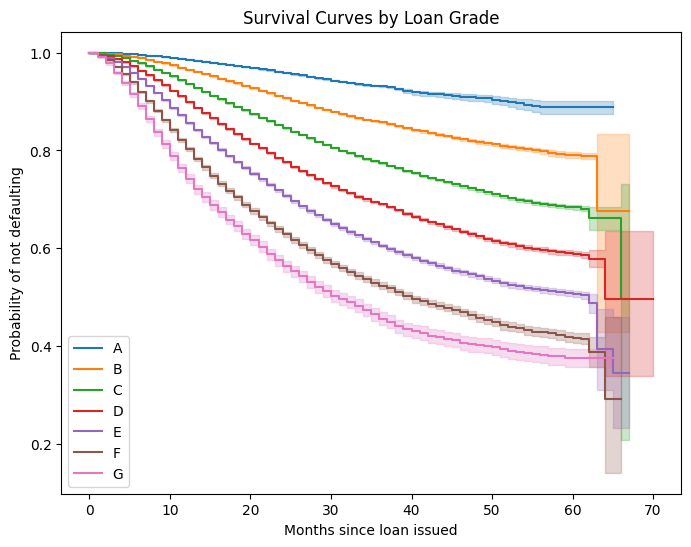

In [59]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8,6))

for grade in sorted(loan['grade'].unique()):
    mask = loan['grade'] == grade
    kmf.fit(durations=loan[mask]['duration'], event_observed=loan[mask]['event'])
    kmf.plot_survival_function(ax=ax, label=grade)

plt.title("Survival Curves by Loan Grade")
plt.xlabel("Months since loan issued")
plt.ylabel("Probability of not defaulting")
plt.show()

## 5. Feature Cleaning: Term and Employment Length

Converting `term` from text ("36 months") to a numeric value, and mapping `emp_length`
text categories ("10+ years", "< 1 year", etc.) to numbers 0-10. About 39% of borrowers
had `emp_length = 'n/a'`, which was captured in a separate `emp_length_missing` flag before
filling the remaining values with the median — preserving the "we don't know" signal
rather than discarding it.
 

In [60]:
covariates = ['term', 'int_rate', 'annual_inc', 'dti', 'home_ownership', 
               'purpose', 'emp_length', 'verification_status', 'revol_util', 
               'open_acc', 'total_acc', 'grade']

In [61]:
loan[covariates].isna().sum()

term                   0
int_rate               0
annual_inc             0
dti                    0
home_ownership         0
purpose                0
emp_length             0
verification_status    0
revol_util             0
open_acc               0
total_acc              0
grade                  0
dtype: int64

In [62]:
loan['term']= loan['term'].str.replace( ' months' , '').astype(int)

In [64]:
loan["emp_length"].unique()

<StringArray>
['10+ years',   '6 years',  '< 1 year',   '2 years',   '4 years',   '9 years',
   '5 years',   '3 years',   '7 years',    '1 year',   '8 years']
Length: 11, dtype: str

In [65]:
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    # ... fill in the rest based on what .unique() showed you
    '10+ years': 10
}

loan['emp_length'] = loan['emp_length'].map(emp_length_map)

In [66]:
loan[['term', 'emp_length']].dtypes
loan[['term', 'emp_length']].describe()

,term,emp_length
count,2.075694e+06,1.266723e+06
mean,4.300204e+01,6.237648e+00
std,1.090965e+01,4.462254e+00
min,3.600000e+01,0.000000e+00
25%,3.600000e+01,1.000000e+00
50%,3.600000e+01,1.000000e+01
75%,6.000000e+01,1.000000e+01
max,6.000000e+01,1.000000e+01


In [67]:
loan[['term', 'emp_length']].dtypes

term            int64
emp_length    float64
dtype: object

In [68]:
loan['emp_length'].isna().sum()

np.int64(808971)

In [69]:
loan['emp_length_missing'] = loan['emp_length'].isna().astype(int)

In [70]:
loan['emp_length'] = loan['emp_length'].fillna(loan['emp_length'].median())

In [71]:
loan[['term','emp_length','emp_length_missing']].describe()
loan['emp_length'].isna().sum()

np.int64(0)

In [72]:
loan[['term','emp_length','emp_length_missing']].describe()

,term,emp_length,emp_length_missing
count,2.075694e+06,2.075694e+06,2.075694e+06
mean,4.300204e+01,7.703969e+00,3.897352e-01
std,1.090965e+01,3.939306e+00,4.876903e-01
min,3.600000e+01,0.000000e+00,0.000000e+00
25%,3.600000e+01,2.000000e+00,0.000000e+00
50%,3.600000e+01,1.000000e+01,0.000000e+00
75%,6.000000e+01,1.000000e+01,1.000000e+00
max,6.000000e+01,1.000000e+01,1.000000e+00


## 6. Encoding Categorical Variables

One-hot encoding `grade`, `home_ownership`, `purpose`, and `verification_status` into dummy
variables (with `drop_first=True`) so they can be used as numeric inputs to the Cox and
logistic regression models.

In [73]:
categorical_cols = ['grade', 'home_ownership', 'purpose', 'verification_status']

dummies = pd.get_dummies(loan[categorical_cols], drop_first=True)

In [75]:
dummies.columns.tolist()


['grade_B',
 'grade_C',
 'grade_D',
 'grade_E',
 'grade_F',
 'grade_G',
 'home_ownership_MORTGAGE',
 'home_ownership_NONE',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'purpose_credit_card',
 'purpose_debt_consolidation',
 'purpose_educational',
 'purpose_home_improvement',
 'purpose_house',
 'purpose_major_purchase',
 'purpose_medical',
 'purpose_moving',
 'purpose_other',
 'purpose_renewable_energy',
 'purpose_small_business',
 'purpose_vacation',
 'purpose_wedding',
 'verification_status_Source Verified',
 'verification_status_Verified']

In [76]:
dummies.shape

(2075694, 26)

In [78]:
numeric_covariates = ['term', 'int_rate', 'annual_inc', 'dti', 'emp_length', 
                       'emp_length_missing', 'revol_util', 'open_acc', 'total_acc']

cox_data = pd.concat([loan[numeric_covariates], dummies, loan[['duration', 'event']]], axis=1)


In [79]:

cox_data.isna().sum().sum()

np.int64(0)

In [80]:
cox_data.shape

(2075694, 37)

## 7. Cox Proportional Hazards Model
 
Fitting a Cox Proportional Hazards model on a 200,000-loan sample using 35 covariates
(loan terms, borrower financials, and the encoded categorical variables). Key results:
 
- **Concordance: 0.69**
- **Grade** is the dominant predictor — relative to grade A, hazard ratios rise from 1.94
  (grade B) up to 5.22 (grade G), meaning a grade G loan defaults at roughly 5x the rate of
  a grade A loan, holding other factors constant
- **Interest rate** (HR 1.06) and **DTI** add incremental predictive power beyond grade
- **Home ownership** is not statistically significant in this model
- **Verification status** shows a counterintuitive *positive* association with default —
  likely a selection effect, since Lending Club tends to verify income specifically for
  riskier-looking applications


In [81]:
sample = cox_data.sample(n=200000, random_state=42)

In [85]:
cph = CoxPHFitter()
cph.fit(sample, duration_col='duration', event_col='event')

C:\Users\MM COMPUTERS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['home_ownership_NONE', 'home_ownership_OTHER'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 200000 total observations, 176785 right-censored observations>

In [86]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 200000 total observations, 176785 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200000
number of events observed = 23215
   partial log-likelihood = -262259.43
         time fit was run = 2026-06-14 07:02:24 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
term                                -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
int_rate                             0.06      1.06      0.00            0.05            0.06                1.05                1.07
annual_inc                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
dti                                  0.00      1.00      0.00            0.00            0.00                1.00                1.00
emp_length                          -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
emp_length_missing                   0.06      1.07      0.02            0.03            0.09                1.03                1.10
revol_util                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
open_acc                             0.00      1.00      0.00           -0.00            0.01                1.00                1.01
total_acc                            0.01      1.01      0.00            0.00            0.01                1.00                1.01
grade_B                              0.66      1.94      0.04            0.59            0.74                1.81                2.09
grade_C                              1.04      2.82      0.04            0.95            1.12                2.59                3.07
grade_D                              1.26      3.53      0.06            1.15            1.37                3.17                3.93
grade_E                              1.37      3.95      0.07            1.24            1.51                3.46                4.51
grade_F                              1.49      4.46      0.08            1.33            1.66                3.78                5.25
grade_G                              1.65      5.22      0.10            1.45            1.85                4.28                6.37
home_ownership_MORTGAGE              0.06      1.06      0.50           -0.92            1.04                0.40                2.82
home_ownership_NONE                  0.23      1.26      0.87           -1.47            1.93                0.23                6.87
home_ownership_OTHER                 0.35      1.41      0.87           -1.35            2.04                0.26                7.73
home_ownership_OWN                   0.17      1.19      0.50           -0.81            1.15                0.45                3.17
home_ownership_RENT                  0.26      1.30      0.50           -0.72            1.24                0.49                3.45
purpose_credit_card                  0.20      1.22      0.08            0.05            0.35                1.05                1.43
purpose_debt_consolidation           0.26      1.30      0.08            0.11            0.41                1.11                1.51
purpose_educational                  0.41      1.51      0.42           -0.40            1.22                0.67                3.40
purpose_home_improvement             0.22      1.25      0.08            0.06            0.38                1.06                1.47
purpose_house                        0.13      1.14      0.11           -0.09            0.36                0.91                1.43
purpose

## 8. Logistic Regression Benchmark
 
Fitting a standard logistic regression on the same 200k sample and same 35 features, with
`event` as a binary target. Result: **AUC = 0.631**, noticeably lower than the Cox model's
concordance of 0.69.
 

In [91]:
from sklearn.model_selection import train_test_split

feature_cols = [col for col in sample.columns if col not in ['duration', 'event']]

X = sample[feature_cols]
y = sample['event']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

C:\Users\MM COMPUTERS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [93]:
from sklearn.metrics import roc_auc_score

y_pred_proba = logreg.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(auc)

0.6310962477043537


## 9. Model Comparison: Cox vs Logistic Regression
 
The Cox model outperforms logistic regression (0.69 vs 0.631) despite using identical
input features. The likely explanation is how each model treats "Current" (still active)
loans: logistic regression labels them identically to "Fully Paid" loans, even though a
loan that's only 2-3 months old simply hasn't had time to reveal its outcome. The Cox
model's censoring framework uses this partial information more honestly, extracting more
signal from the same data — directly supporting the case for survival analysis over plain
binary classification in credit risk.

## 10. IFRS 9 / Expected Credit Loss Application

Using the grade-level Kaplan-Meier curves, 12-month and 36-month default probabilities
(PD) were extracted for each grade, along with a "cliff ratio" (36-month PD / 12-month PD):
 
 
Both PD measures increase steadily from grade A to G, as expected. More interesting is the
**cliff ratio, which decreases** from A to G — for grade A, lifetime risk is nearly 5x the
12-month figure (risk is "back-loaded," often triggered by later life events), while for
grade G it's only ~2x (risk is "front-loaded," with financially stressed borrowers failing
early if they're going to fail at all). Under IFRS 9, a Stage 1 → Stage 2 migration
(12-month ECL → lifetime ECL) therefore has a proportionally larger provisioning impact for
higher-grade loans than for lower-grade loans.
 

In [96]:
results = []

for grade in sorted(loan['grade'].unique()):
    mask = loan['grade'] == grade
    kmf.fit(durations=loan[mask]['duration'], event_observed=loan[mask]['event'])
    
    survival_12 = kmf.predict(12)
    survival_36 = kmf.predict(36)
    
    pd_12 = 1 - survival_12
    pd_36 = 1 - survival_36
    
    results.append({
        'grade': grade,
        'PD_12mo': pd_12,
        'PD_36mo': pd_36,
        'cliff_ratio': pd_36 / pd_12
    })

results_df = pd.DataFrame(results)
print(results_df)

  grade   PD_12mo   PD_36mo  cliff_ratio
0     A  0.013936  0.068577     4.921029
1     B  0.034873  0.142092     4.074606
2     C  0.064246  0.225581     3.511191
3     D  0.100761  0.309867     3.075252
4     E  0.143585  0.394482     2.747377
5     F  0.197463  0.476641     2.413827
6     G  0.257924  0.544287     2.110264
